# 🚗 Car Price Prediction Model (Linear Regression)
**Objective:** Predict the price of automobiles based on various technical and physical specifications using a Multiple Linear Regression model. We utilize an end-to-end `scikit-learn` pipeline for automated data preprocessing and modeling.

In [1]:
# 1. Import Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(" Libraries Imported Successfully")

 Libraries Imported Successfully



### 📂 Step 1: Load and Inspect the Data
We load the `imports.csv` dataset. Since our goal is to predict the `price`, any row missing the target variable is useless for training, so we will drop those specific rows immediately.

In [2]:
# Load Dataset
df = pd.read_csv('imports.csv')

# Drop rows where the target variable ('price') is missing
df.dropna(subset=['price'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dataset Shape after dropping missing targets: {df.shape}")
display(df.head(3))

Dataset Shape after dropping missing targets: (201, 25)


,symboling,normalized-losses,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0




### 📊 Step 1.5: Exploratory Data Analysis (EDA)
Before building the model, let's visualize the relationship between some key features and the target variable (`price`).

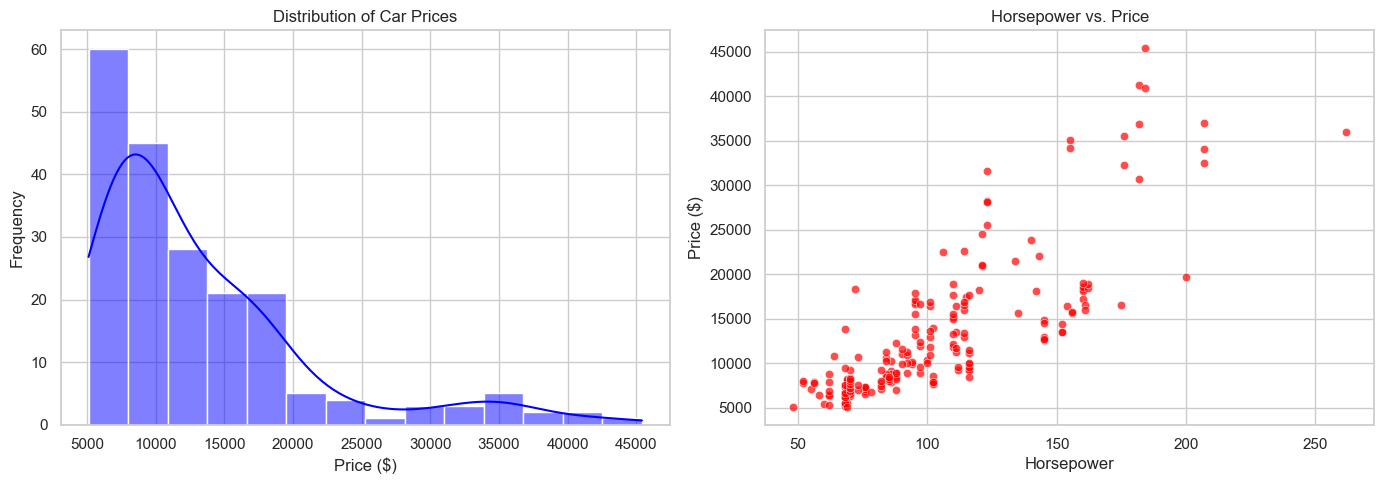

In [3]:
# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 5))

# Plot 1: Distribution of Car Prices
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, color='blue')
plt.title('Distribution of Car Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')

# Plot 2: Horsepower vs Price
plt.subplot(1, 2, 2)
# Convert horsepower to numeric just in case it's read as object
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce') 
sns.scatterplot(x='horsepower', y='price', data=df, color='red', alpha=0.7)
plt.title('Horsepower vs. Price')
plt.xlabel('Horsepower')
plt.ylabel('Price ($)')

plt.tight_layout()
plt.show()

### ✂️ Step 2: Feature Separation & Data Splitting

In [4]:
# Separate Features (X) and Target (y)
X = df.drop('price', axis=1)
y = df['price']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify numerical and categorical columns automatically
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns


### 🏗️ Step 3: Build the ML Pipeline (Preprocessing + Model)
Instead of applying preprocessing manually, we build a unified pipeline that cleans, transforms, and trains the `LinearRegression` model in one block of code.

In [5]:
# 1. Numerical Preprocessing
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Fill missing with median
    ('scaler', StandardScaler())                   # Scale features
])

# 2. Categorical Preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Fill missing with mode
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # One-hot encoding
])

# 3. Combine Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# 4. Create the FULL Model Pipeline (Preprocessor + Regressor)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

print(" Full Machine Learning Pipeline Built Successfully!")

 Full Machine Learning Pipeline Built Successfully!



### 🚀 Step 4: Train and Evaluate the Model

In [6]:
# Train the model (this automatically preprocesses X_train and fits the Regression model)
model_pipeline.fit(X_train, y_train)

# Make Predictions on the testing set
y_pred = model_pipeline.predict(X_test)

# Evaluate the Model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(" Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R2) Score: {r2:.4f}") # How much variance the model explains

 Model Evaluation Metrics:
Mean Absolute Error (MAE): $2,571.25
Root Mean Squared Error (RMSE): $3,790.79
R-squared (R2) Score: 0.8825



### 📈 Step 5: Visualizing Model Performance
A great way to evaluate a regression model is to plot the **Actual Prices vs. Predicted Prices**. In a perfect model, all points would lie on a straight 45-degree diagonal line.

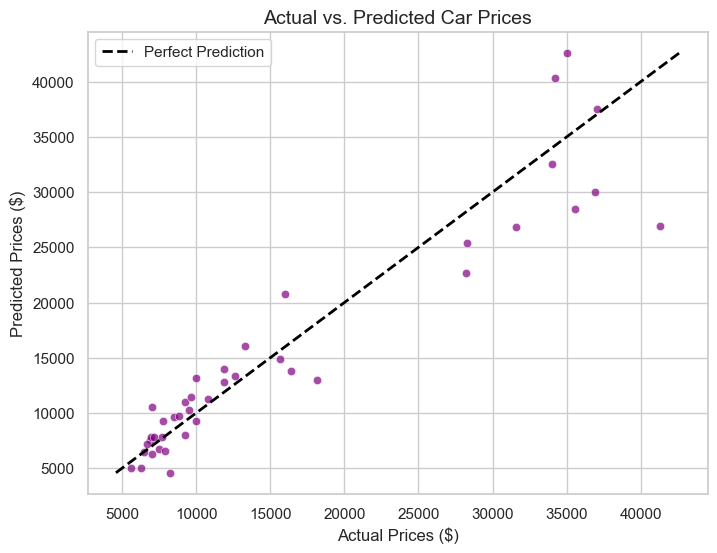

In [7]:
plt.figure(figsize=(8, 6))

# Scatter plot of Actual vs Predicted
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='purple')

# Plotting the perfect prediction diagonal line
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted Car Prices', fontsize=14)
plt.xlabel('Actual Prices ($)', fontsize=12)
plt.ylabel('Predicted Prices ($)', fontsize=12)
plt.legend()
plt.show()